<div style="display: flex; align-items: center;">
    <div style="display: flex; flex-direction: column; align-items: center;">
        <h1 style="text-align: right;">Centro de Investigación en Matemáticas, A.C.</h1>
        <h2 style="text-align: right;">Modelos Generativos Profundos</h2>
        <h2 style="text-align: right;">Jose Miguel Saavedra Aguilar</h2>
        <h3 style="text-align: right;">Tarea 3</h3>
    </div>
    <img src="https://www.cimat.mx/~adolfofest/images/LOGOTIPO_SIN_FONDO-02.png" alt="CIMAT Logo" width="200" style="float: left;">
</div>


---

## Problema 2
Implementa el método de sliced score matching en PyTorch para generar imágenes a partir de los datos de MNIST.

Implementamos el método de Latent Sliced Score Matching, una variante en la que utilizamos Sliced Score Matching en el espacio latente de un variational autoencoder para evitar las suposiciones del encoder y del espacio latente, por ejemplo, normalidad. Esto fue resultado de que el método de Sliced Score Matching en el espacio de pixeles no generaba correctamente los dígitos, incluso cuando logré que el resultado no fuera ruido puro, se generaban imágenes negras con algunos círuclos blancos, no dígitos. Este método me parece una forma mucho más tractable de implementar SSM, pues en el espacio de pixeles el método es muy sensible a parámetros, tasa de aprendizaje, etc. además que tarda casi un día de entrenamiento para conseguir resultados que no sean totalmente ruido.

Estos métodos fueron propuestos por Arash Vahdat, Karsten Kreis, Jan Kautz y se pueden consultar en https://arxiv.org/abs/2106.05931?spm=a2ty_o01.29997173.0.0.6792c921605cct&file=2106.05931

In [ ]:
!pip install torchinfo

In [ ]:
# Core imports for PyTorch, datasets, and plotting.
import math, os, gc, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
# Optional helper to print model summaries (not required for training).
from torchinfo import summary
from torchmetrics import MeanMetric


In [ ]:
# Device selection: choose GPU if available, else CPU.
# Also detects common TPU environment variables used in hosted notebooks.
# This makes subsequent `.to(device)` calls portable.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif 'TPU_ACCELERATOR_TYPE' in os.environ or 'COLAB_TPU_1vm' in os.environ:
    # Minimal TPU support if running in an environment that exposes XLA.
    import torch_xla
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


Using device: cuda


Dicho lo anterior, utilizaremos la VAE de la tarea 2 que sabemos generaba los dígitos de MNIST decentemente, sin embargo aún eran un poco borrosos. Únicamente la modificamos a ser condicionada por el valor real del dígito para mejores resultados. Esto lo hacemos a través de un embedding.

In [ ]:
# ----------------------------
# Data loaders: one for VAE training ([0,1] range),
# and one (optional) for SSM-related augmentations in [-1,1].
# VAE uses sigmoid outputs so inputs are scaled to [0,1].
transform_vae = transforms.Compose([
    transforms.ToTensor(),  # outputs tensor in [0,1]
])

train_dataset_vae = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform_vae
)
train_loader_vae = DataLoader(train_dataset_vae, batch_size=128, shuffle=True, num_workers=0)

# Augmented loader scaled to [-1,1] (used for SSM in pixel space experiments).
# Padding and small rotations are applied as minimal augmentation.
transform_ssm = transforms.Compose([
    transforms.Pad(2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    lambda x: x * 2 - 1  # map [0,1] -> [-1,1]
])
train_dataset_ssm = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform_ssm
)
train_loader_ssm = DataLoader(train_dataset_ssm, batch_size=128, shuffle=True, num_workers=0)


In [ ]:
# ----------------------------
# VAE helper: reparameterization trick
# Converts (mu, log_var) -> sample z = mu + sigma * eps, where eps~N(0,I).
def reparameterize(mu, log_var):
    # log_var is log(sigma^2); compute sigma and sample noise of same shape.
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std


In [ ]:
# Conditional encoder: takes flattened image x and label y, returns (mu, log_var).
# We use an embedding to condition on the digit class and concatenate it to the input.
class ConditionalEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim, num_classes=10):
        super().__init__()
        # Embedding provides a learned per-class vector to condition the encoder.
        self.embed = nn.Embedding(num_classes, hidden_dim)
        # FC expects flattened image concatenated with class embedding.
        self.fc1 = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)

    def forward(self, x, y):
        # x: [B, input_dim], y: [B] (labels)
        class_emb = self.embed(y)  # [B, hidden_dim]
        h = torch.cat([x, class_emb], dim=1)
        h = F.relu(self.fc1(h))
        mu = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        return mu, log_var


In [ ]:
# Conditional decoder: maps latent z and label y back to image space.
# Outputs are squashed with sigmoid to match [0,1] image range used for VAE.
class ConditionalDecoder(nn.Module):
    def __init__(self, z_dim, hidden_dim, output_dim, num_classes=10):
        super().__init__()
        self.embed = nn.Embedding(num_classes, hidden_dim)
        self.fc1 = nn.Linear(z_dim + hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, y):
        class_emb = self.embed(y)
        h = torch.cat([z, class_emb], dim=1)
        h = F.relu(self.fc1(h))
        # Sigmoid to give pixel intensities in [0,1] for the VAE reconstruction loss.
        return torch.sigmoid(self.fc_out(h))


In [ ]:
# Simple conditional VAE wrapper combining encoder and decoder.
class ConditionalVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim, num_classes=10):
        super().__init__()
        self.encoder = ConditionalEncoder(input_dim, hidden_dim, z_dim, num_classes)
        self.decoder = ConditionalDecoder(z_dim, hidden_dim, input_dim, num_classes)

    def forward(self, x, y):
        # Returns reconstructed x and the encoder's (mu, log_var).
        mu, log_var = self.encoder(x, y)
        z = reparameterize(mu, log_var)
        x_recon = self.decoder(z, y)
        return x_recon, mu, log_var


Primero, debemos entrenar el VAE utilizando el ELBO como en un VAE usual, por lo que así lo haremos.

In [ ]:
# ----------------------------
# VAE loss (ELBO): reconstruction + KL divergence.
# We treat the reconstruction term as an MSE (Gaussian NLL with fixed variance).
def vae_loss(x, x_recon, mu, log_var):
    # Reconstruction loss summed over all elements (matches typical ELBO formulation).
    recon_loss = F.mse_loss(x_recon, x, reduction="sum")
    # KL divergence between q(z|x) ~ N(mu, sigma^2) and p(z) ~ N(0,I).
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_loss


In [ ]:
# ----------------------------
# Hyperparameters and model sizes (tune as needed).
input_dim = 28 * 28
hidden_dim = 512
z_dim = 32  # latent dimension (lower dims make SSM cheaper but may reduce fidelity)
epochs_vae = 100
lr_vae = 1e-3

In [ ]:
# ----------------------------
# Stage 1: Train the conditional VAE (reconstruction + KL).
# We train the VAE so that the latent space is a good representation for SSM.
print("=== Stage 1: Training Conditional VAE ===")
vae = ConditionalVAE(input_dim, hidden_dim, z_dim, num_classes=10).to(device)
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=lr_vae)

vae.train()


=== Stage 1: Training Conditional VAE ===


ConditionalVAE(
  (encoder): ConditionalEncoder(
    (embed): Embedding(10, 512)
    (fc1): Linear(in_features=1296, out_features=512, bias=True)
    (fc_mu): Linear(in_features=512, out_features=32, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=32, bias=True)
  )
  (decoder): ConditionalDecoder(
    (embed): Embedding(10, 512)
    (fc1): Linear(in_features=544, out_features=512, bias=True)
    (fc_out): Linear(in_features=512, out_features=784, bias=True)
  )
)

In [ ]:
# Standard training loop for the VAE. Note: x is flattened before passing.
for epoch in range(epochs_vae):
    total_loss = 0.0
    for batch_idx, (x, y) in enumerate(train_loader_vae):
        # Flatten images to vectors and move to device
        x = x.view(x.size(0), -1).to(device)
        y = y.to(device)  # move labels to device

        vae_optimizer.zero_grad()
        x_recon, mu, log_var = vae(x, y)  # pass y to VAE!
        loss = vae_loss(x, x_recon, mu, log_var)
        loss.backward()
        vae_optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader_vae.dataset)
    print(f"VAE Epoch {epoch+1}/{epochs_vae} | Avg ELBO per sample: {avg_loss:.4f}")


VAE Epoch 1/100 | Avg ELBO per sample: 42.5661
VAE Epoch 2/100 | Avg ELBO per sample: 36.5607
VAE Epoch 3/100 | Avg ELBO per sample: 34.3304
VAE Epoch 4/100 | Avg ELBO per sample: 32.1706
VAE Epoch 5/100 | Avg ELBO per sample: 30.9998
VAE Epoch 6/100 | Avg ELBO per sample: 30.0466
VAE Epoch 7/100 | Avg ELBO per sample: 29.2962
VAE Epoch 8/100 | Avg ELBO per sample: 28.6727
VAE Epoch 9/100 | Avg ELBO per sample: 28.2886
VAE Epoch 10/100 | Avg ELBO per sample: 27.9980
VAE Epoch 11/100 | Avg ELBO per sample: 27.8042
VAE Epoch 12/100 | Avg ELBO per sample: 27.6130
VAE Epoch 13/100 | Avg ELBO per sample: 27.4927
VAE Epoch 14/100 | Avg ELBO per sample: 27.3862
VAE Epoch 15/100 | Avg ELBO per sample: 27.3128
VAE Epoch 16/100 | Avg ELBO per sample: 27.2057
VAE Epoch 17/100 | Avg ELBO per sample: 27.1402
VAE Epoch 18/100 | Avg ELBO per sample: 27.0624
VAE Epoch 19/100 | Avg ELBO per sample: 26.9838
VAE Epoch 20/100 | Avg ELBO per sample: 26.9187
VAE Epoch 21/100 | Avg ELBO per sample: 26.8703
V

In [ ]:
# Save the trained VAE weights for reuse later (decoder used by SSM sampler).
torch.save(vae.state_dict(), "vae_mnist.pth")
print("VAE trained and saved.")


VAE trained and saved.


In [ ]:
# Load the trained Conditional VAE from disk and prepare for inference
vae = ConditionalVAE(input_dim, hidden_dim, z_dim, num_classes=10).to(device)
try:
    state = torch.load("vae_mnist.pth", map_location=device)
    vae.load_state_dict(state)
    vae.eval()
    print("Loaded vae_mnist.pth -> vae (eval mode) on", device)
except Exception as e:
    print("Failed to load vae_mnist.pth:", e)

Ahora, creamos la red de score, en este caso podemos utilizar una MLP, mientras que cuando trabajamos en el espacio de pixeles estabamos utilizando una U-NET como lo dijimos en clase.

Ahora reemplazamos SSM por un modelo de difusión DDPM/DDIM en el espacio latente, usando la arquitectura UNet y embeddings sinusoidales para el tiempo.

In [ ]:
# DDPM/DDIM utilities for latent diffusion

# Beta schedule (cosine or linear, here linear for simplicity)
def make_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

T = 1000  # Number of diffusion steps
betas = make_beta_schedule(T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)

def extract(a, t, x_shape):
    # Helper to extract t-indexed values for each batch element
    b = t.shape[0]
    out = a.gather(-1, t).float()
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))


In [ ]:
def get_from_idx(element: torch.Tensor, idx: torch.Tensor):
    ele = element.gather(-1, idx)
    return ele.reshape(-1, 1, 1, 1)

# This class will be use for implementing the forward diffusion process
class ForwardSampler(nn.Module):
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=2e-2):
        super().__init__()
        # Total number of steps in the diffusion process
        self.timesteps = timesteps
        # The betas and the alphas
        beta = torch.linspace(
                beta_start,
                beta_end,
                self.timesteps,
                dtype=torch.float32
            )
        self.register_buffer("beta", beta)
        # Some intermediate values that we will use
        self.register_buffer("alpha", 1 - self.beta)
        self.register_buffer("alpha_bar", torch.cumprod(self.alpha, dim=0))
        self.register_buffer("sqrt_alpha_bar", torch.sqrt(self.alpha_bar))
        self.register_buffer("one_by_sqrt_alpha", 1. / torch.sqrt(self.alpha))
        self.register_buffer("sqrt_one_minus_alpha_bar", torch.sqrt(1 - self.alpha_bar))

    # We use directly q(x_t|x_0) to generate one x_t given x_0.
    # This avoids to do all the individual diffusion steps.
    def forward(self, x0: torch.Tensor, timesteps: torch.Tensor):
        # Generate normal noise
        epsilon = torch.randn_like(x0)
        # Get the mean/standard deviation for the queried timesteps
        mean    = get_from_idx(self.sqrt_alpha_bar, timesteps) * x0      # Mean
        std_dev = get_from_idx(self.sqrt_one_minus_alpha_bar, timesteps) # Standard deviation
        # Sample is mean plus the scaled noise
        sample  = mean + std_dev * epsilon
        return sample, epsilon

In [ ]:
# This is a class that derives from ForwardSampler
# and that will add the posibility to do one step backwards
class DDPM(ForwardSampler):
    # This will implement one step back in the reverse process
    def step_backward(self, predicted_noise:torch.Tensor, xnoise:torch.Tensor, timestep: int):
        # Noise from normal distribution
        z  = torch.randn_like(xnoise) if timestep > 0 else torch.zeros_like(xnoise)
        beta_t                     = self.beta[timestep].reshape(-1, 1, 1, 1)
        one_by_sqrt_alpha_t        = self.one_by_sqrt_alpha[timestep].reshape(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bar[timestep].reshape(-1, 1, 1, 1)
        # Use the formula above to sample a denoised version from the noisy one
        xdenoised = (
            one_by_sqrt_alpha_t
            * (xnoise - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise)
            + torch.sqrt(beta_t) * z
        )
        return xdenoised

In [ ]:
def train_step(batch:torch.Tensor, model:nn.Module, forwardsampler:DDPM):
    # Sample a timestep uniformly
    t = torch.randint(low=0, high=forwardsampler.timesteps, size=(batch.shape[0],), device=batch.device)
    # Apply forward noising process on original images, up to step t (sample from q(x_t|x_0))
    x_noisy, eps_true = forwardsampler(batch, t)
    with amp.autocast():
        # Our prediction for the denoised image
        eps_predicted = model(x_noisy, t)
        # Deduce the loss
        loss          = F.mse_loss(eps_predicted, eps_true)
    return loss

In [ ]:
# This is how we will use the model once trained
@torch.inference_mode()
def generate(denoiser_model:nn.Module, backward_sampler:DDPM, size, device):
    # Noise from a normal distribution
    x_T = torch.randn(size, device=device)
    # Now, to reverse the diffusion process, use a sequence of denoising steps
    # for t in reversed(range(backward_sampler.timesteps)):
    for t in tqdm(iterable=reversed(range(0, backward_sampler.timesteps)),
                          dynamic_ncols=False,total=backward_sampler.timesteps,
                          desc="Sampling :: ", position=0):
        t_tensor = torch.as_tensor(t, dtype=torch.long, device=device).reshape(-1).expand(xnoisy.shape[0])
        # Estimate the noise
        eps_pred = denoiser_model(x_T, t_tensor)
        # Denoise with the sampler and the estimation of the noise
        x_T= backward_sampler.step_backward(eps_pred, x_T, t)
    return x_T

In [ ]:
# sinusoidal time embedding (as in DDPM / Transformer)
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) * (math.log(10000) / (half - 1))
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=1)


In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, total_time_steps=1000, time_emb_dims=128, time_emb_dims_exp=512):
        super().__init__()
        self.total_time_steps = total_time_steps
        self.time_emb_dims = time_emb_dims
        self.time_emb_dims_exp = time_emb_dims_exp

        half_dim = time_emb_dims // 2
        emb = math.log(10000) / (half_dim - 1 + 1e-8)  # avoid div by zero
        freqs = torch.exp(torch.arange(half_dim, dtype=torch.float32) * -emb)  # [half_dim]
        ts = torch.arange(total_time_steps, dtype=torch.float32).unsqueeze(1)   # [T, 1]
        emb_table = torch.cat([
            torch.sin(ts * freqs),
            torch.cos(ts * freqs)
        ], dim=-1)  # [T, time_emb_dims]

        self.register_buffer("emb_table", emb_table)  # auto moves with model to device

        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dims, time_emb_dims_exp),
            nn.SiLU(),
            nn.Linear(time_emb_dims_exp, time_emb_dims_exp),
        )

    def forward(self, time):
        # time: [B], dtype=torch.long, values in [0, total_time_steps)
        emb = self.emb_table[time]  # [B, time_emb_dims]
        return self.time_mlp(emb)   # [B, time_emb_dims_exp]

In [ ]:
# Attention block
class AttentionBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.channels  = channels
        self.group_norm= nn.GroupNorm(num_groups=8,num_channels=channels)
        self.mhsa      = nn.MultiheadAttention(embed_dim=self.channels,num_heads=4,batch_first=True)

    def forward(self, x):
        B, _, H, W = x.shape
        h          = self.group_norm(x)
        h          = h.reshape(B, self.channels, H * W).swapaxes(1, 2)  # [B, C, H, W] --> [B, C, H * W] --> [B, H*W, C]
        h, _       = self.mhsa(h, h, h)  # [B, H*W, C]
        h          = h.swapaxes(2, 1).view(B, self.channels, H, W)  # [B, C, H*W] --> [B, C, H, W]
        return x + h

In [ ]:
# Resnet block
class ResnetBlock(nn.Module):
    def __init__(self, *, in_channels, out_channels, dropout_rate=0.1, time_emb_dims=512, apply_attention=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels= out_channels

        self.activation  = nn.SiLU()
        # Group 1
        self.normalize_1 = nn.GroupNorm(num_groups=8, num_channels=self.in_channels)
        self.conv_1      = nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=3, stride=1, padding="same")

        # Group 2 time embedding
        self.dense_1    = nn.Linear(in_features=time_emb_dims, out_features=self.out_channels)

        # Group 3
        self.normalize_2= nn.GroupNorm(num_groups=8, num_channels=self.out_channels)
        self.dropout    = nn.Dropout2d(p=dropout_rate)
        self.conv_2     = nn.Conv2d(in_channels=self.out_channels, out_channels=self.out_channels, kernel_size=3, stride=1, padding="same")

        if self.in_channels != self.out_channels:
            self.match_input = nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=1, stride=1)
        else:
            self.match_input = nn.Identity()

        if apply_attention:
            self.attention = AttentionBlock(channels=self.out_channels)
        else:
            self.attention = nn.Identity()

    def forward(self, x, t):
        # Group 1
        h = self.activation(self.normalize_1(x))
        h = self.conv_1(h)

        # Group 2
        # add in timestep embedding
        h += self.dense_1(self.activation(t))[:, :, None, None]

        # Group 3
        h = self.activation(self.normalize_2(h))
        h = self.dropout(h)
        h = self.conv_2(h)

        # Residual and attention
        h = h + self.match_input(x)
        h = self.attention(h)

        return h



In [ ]:
# Downsampling-convolutive layer
class DownSample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.downsample = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, stride=2, padding=1)
    def forward(self, x, *args):
        return self.downsample(x)

# Upsampling-convolutive layer
class UpSample(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=3, stride=1, padding=1))
    def forward(self, x, *args):
        return self.upsample(x)



In [ ]:
# U-Net borrowed from class. Session 26: Flow matching
# The UNet
class UNet(nn.Module):
    def __init__(
        self,
        input_channels = 3,
        output_channels= 3,
        num_res_blocks = 2,
        base_channels  = 128,
        # Resolutions
        base_channels_multiples=(1, 2, 4, 8),
        # Attention, per resolution level
        apply_attention=(False, False, True, False),
        dropout_rate=0.1,
        time_multiple=4,
        num_classes=10,
    ):
        super().__init__()

        time_emb_dims_exp = base_channels * time_multiple
        self.time_embeddings = SinusoidalPositionEmbeddings(time_emb_dims=base_channels, time_emb_dims_exp=time_emb_dims_exp)
        self.class_emb = nn.Embedding(num_classes, time_emb_dims_exp)
        self.first = nn.Conv2d(in_channels=input_channels, out_channels=base_channels, kernel_size=3, stride=1, padding="same")

        num_resolutions = len(base_channels_multiples)

        # Encoder part of the UNet. Dimension reduction.
        self.encoder_blocks = nn.ModuleList()
        curr_channels = [base_channels]
        in_channels = base_channels

        # For each resolution level
        for level in range(num_resolutions):
            # Number of output channels for this level
            out_channels = base_channels * base_channels_multiples[level]

            # For each residual block
            for _ in range(num_res_blocks):
                # Create block
                block = ResnetBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp * 2,
                    apply_attention=apply_attention[level],
                )
                self.encoder_blocks.append(block)
                in_channels = out_channels
                curr_channels.append(in_channels)

            # For all the levels before the last, add a DownSample
            if level != (num_resolutions - 1):
                self.encoder_blocks.append(DownSample(channels=in_channels))
                curr_channels.append(in_channels)

        # Bottleneck between the encoder and decoder
        self.bottleneck_blocks = nn.ModuleList(
            (
                ResnetBlock(
                    in_channels=in_channels,
                    out_channels=in_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp * 2,
                    apply_attention=True,
                ),
                ResnetBlock(
                    in_channels=in_channels,
                    out_channels=in_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp * 2,
                    apply_attention=False,
                ),
            )
        )

        # Decoder part of the UNet. Dimension restoration with skip-connections.
        self.decoder_blocks = nn.ModuleList()

        # Decoder
        for level in reversed(range(num_resolutions)):
            out_channels = base_channels * base_channels_multiples[level]

            for _ in range(num_res_blocks + 1):
                encoder_in_channels = curr_channels.pop()
                block = ResnetBlock(
                    in_channels=encoder_in_channels + in_channels,
                    out_channels=out_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp * 2,
                    apply_attention=apply_attention[level],
                )

                in_channels = out_channels
                self.decoder_blocks.append(block)

            if level != 0:
                self.decoder_blocks.append(UpSample(in_channels))

        # A last convolutional block
        self.final = nn.Sequential(
            nn.GroupNorm(num_groups=8, num_channels=in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels=in_channels, out_channels=output_channels, kernel_size=3, stride=1, padding="same"),
        )

    def forward(self, x, t, y):
        # x: [B, z_dim, 1, 1], t: [B], y: [B]
        time_emb = self.time_embeddings(t)
        class_emb = self.class_emb(y)
        cond_emb = torch.cat([time_emb, class_emb], dim=1)
        h = self.first(x)
        outs = [h]

        # Encoder
        for layer in self.encoder_blocks:
            h = layer(h, cond_emb)
            outs.append(h)

        # Bottleneck
        for layer in self.bottleneck_blocks:
            h = layer(h, cond_emb)

        # Decoder
        for layer in self.decoder_blocks:
            if isinstance(layer, ResnetBlock):
                out = outs.pop()
                # Fix: crop spatial dims to match before concatenation
                if h.shape[2:] != out.shape[2:]:
                    min_h, min_w = min(h.shape[2], out.shape[2]), min(h.shape[3], out.shape[3])
                    h = h[:, :, :min_h, :min_w]
                    out = out[:, :, :min_h, :min_w]
                h = torch.cat([h, out], dim=1)
            h = layer(h, cond_emb)

        h = self.final(h)

        return h

In [ ]:
# ----------------------------
# Stage 2: Train the latent DDPM (UNet) score network
print("\n=== Stage 2: Training Latent DDPM Score Model ===")
for param in vae.parameters():
    param.requires_grad_(False)
vae.eval()

denoiser_model = UNet(
    input_channels=z_dim,
    output_channels=z_dim,
    base_channels=128,
    base_channels_multiples=(1, 2, 2),
    apply_attention=(False, True, True),
    num_res_blocks=2,
    dropout_rate=0.1,
    time_multiple=4,
    num_classes=10,
).to(device)

optimizer = torch.optim.AdamW(denoiser_model.parameters(), lr=1e-4)

loss_fn = nn.MSELoss()

diffusionmodel = DDPM(timesteps = 1000)
diffusionmodel.to(device)
scaler = torch.amp.GradScaler()

ddpm_epochs = 100

In [ ]:
# Training: one epoch for latent diffusion
def train_one_epoch(model, sampler, loader, optimizer, scaler, loss_fn, vae, device, epoch=1):
    loss_record = MeanMetric().to(device)
    model.train()
    vae.eval()  # VAE is frozen
    
    with tqdm(total=len(loader), dynamic_ncols=True) as tq:
        tq.set_description(f"Train :: Epoch: {epoch}")
        for x, y in loader:
            tq.update(1)
            x = x.view(x.size(0), -1).to(device)
            y = y.to(device)
            
            # Get latent z from VAE encoder (no grad)
            with torch.no_grad():
                mu, log_var = vae.encoder(x, y)
                z = reparameterize(mu, log_var)  # [B, z_dim]
                z = z.unsqueeze(-1).unsqueeze(-1)  # [B, z_dim, 1, 1]

            # Sample random t
            t = torch.randint(0, sampler.timesteps, (z.size(0),), device=device)
            # Forward diffusion: q(z_t|z_0)
            z_t, eps_true = sampler(z, t)

            # Forward pass
            with torch.cuda.amp.autocast():
                eps_pred = model(z_t, t, y)
                loss = loss_fn(eps_pred, eps_true)

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            loss_value = loss.detach().item()
            loss_record.update(loss_value)

            tq.set_postfix_str(s=f"Loss: {loss_value:.4f}")

        mean_loss = loss_record.compute().item()

        tq.set_postfix_str(s=f"Epoch Loss: {mean_loss:.4f}")

    return mean_loss

In [ ]:
# Training loop for latent diffusion
for epoch in range(1, ddpm_epochs + 1):
    torch.cuda.empty_cache()
    gc.collect()

    train_one_epoch(
        denoiser_model, diffusionmodel, train_loader_vae, optimizer, scaler, loss_fn, vae, device, epoch=epoch
    )

    # Optionally: add logging, checkpointing, or sampling here
    if epoch % 10 == 0:
        denoiser_model.eval()
        with torch.no_grad():
            y_sample = torch.randint(0, 10, (16,), device=device)
            z_T = torch.randn(16, z_dim, 1, 1, device=device)
            z = z_T
            for t in reversed(range(diffusionmodel.timesteps)):
                t_batch = torch.full((16,), t, device=device, dtype=torch.long)
                eps_pred = denoiser_model(z, t_batch, y_sample)
                z = diffusionmodel.step_backward(eps_pred, z, t)
            x_gen = vae.decoder(z.squeeze(-1).squeeze(-1), y_sample)
            x_gen = x_gen.view(-1, 3, image_size, image_size).cpu().clamp(0, 1)
            grid = torchvision.utils.make_grid(x_gen, nrow=4)
            plt.figure(figsize=(6,6)); plt.axis('off'); plt.title(f"Samples at epoch {epoch}")
            plt.imshow(grid.permute(1,2,0).clamp(0,1)); plt.show()

Train :: Epoch: 1/1:   2%|▏         | 1/63 [00:00<00:09,  6.27it/s]/tmp/ipykernel_7680/1325195101.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
Train :: Epoch: 1/1: 100%|██████████| 63/63 [00:28<00:00,  2.21it/s, Epoch Loss: 0.3187]


In [ ]:
# Save trained DDPM score network
torch.save(denoiser_model.state_dict(), "latent_ddpm_score_net.pth")
print("Latent DDPM score model trained and saved.")


Sampling :: 100%|██████████| 10/10 [00:08<00:00,  1.19it/s]


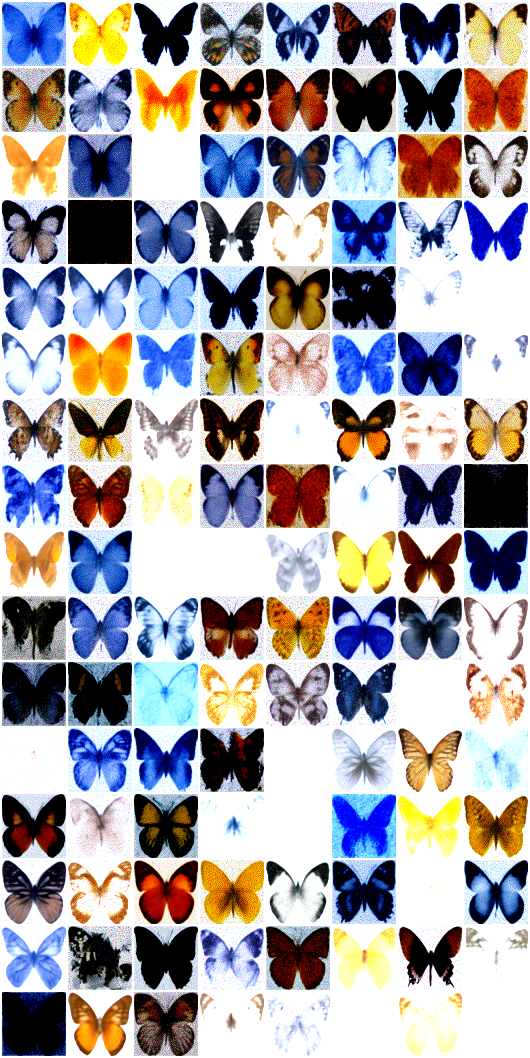

In [ ]:
# DDIM sampling for conditional latent diffusion
@torch.inference_mode()
def generate_ddim(denoiser_model, taus, backward_sampler, size, device, y=None):
    xnoisy = torch.randn(size, device=device)
    # Set the model in evaluation mode
    denoiser_model.eval()
    last_t = torch.ones(size[0], dtype=torch.long, device=device) * (backward_sampler.timesteps-1)
    alpha_bar_t = get_from_idx(backward_sampler.alpha_bar, last_t)
    sqrt_alpha_bar_t = get_from_idx(backward_sampler.sqrt_alpha_bar, last_t)
    sqrt_one_minus_alpha_bar_t = get_from_idx(backward_sampler.sqrt_one_minus_alpha_bar, last_t)
    # Now, to reverse the diffusion process, use a sequence of denoising steps
    for t in tqdm(iterable=reversed(taus),
                          dynamic_ncols=False,total=len(taus),
                          desc="Sampling :: ", position=0):
        # Time vectors
        ts = torch.ones(size[0], dtype=torch.long, device=device) * t
        # If y is not provided, generate random labels for conditional generation
        if y is not None:
            y_cond = y
        else:
            y_cond = torch.randint(0, 10, (size[0],), device=device)
        predicted_noise = denoiser_model(xnoisy, ts, y_cond)
        alpha_bar_t_prev = get_from_idx(backward_sampler.alpha_bar, ts)
        sqrt_alpha_bar_t_prev = get_from_idx(backward_sampler.sqrt_alpha_bar, ts)
        sqrt_one_minus_alpha_bar_t_prev = get_from_idx(backward_sampler.sqrt_one_minus_alpha_bar, ts)
        predicted_x0 = (xnoisy - sqrt_one_minus_alpha_bar_t * predicted_noise) / sqrt_alpha_bar_t
        xnoisy = sqrt_alpha_bar_t_prev * predicted_x0 + sqrt_one_minus_alpha_bar_t_prev * predicted_noise
        alpha_bar_t = alpha_bar_t_prev
        sqrt_alpha_bar_t = sqrt_alpha_bar_t_prev
        sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar_t_prev
    return xnoisy

# Example usage for latent diffusion:
taus = np.arange(0, diffusionmodel.timesteps, 100)
y_sample = torch.randint(0, 10, (16,), device=device)
z_latents = generate_ddim(denoiser_model, taus, diffusionmodel, (16, z_dim, 1, 1), device, y=y_sample)
x_gen = vae.decoder(z_latents.squeeze(-1).squeeze(-1), y_sample)
x_gen = x_gen.view(-1, 1, 28, 28).cpu().clamp(0, 1)
grid = torchvision.utils.make_grid(x_gen, nrow=4)
plt.figure(figsize=(6,6)); plt.axis('off'); plt.title("DDIM Latent Diffusion Samples")
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray'); plt.show()

## LSGM-style Joint Training
Después de entrenar el modelo de difusión latente, descongelamos el VAE y entrenamos ambos modelos conjuntamente como en LSGM.

In [ ]:
# Unfreeze VAE parameters for joint training
for param in vae.parameters():
    param.requires_grad_(True)

# New optimizer for both VAE and diffusion model
joint_optimizer = torch.optim.AdamW(
    list(vae.parameters()) + list(denoiser_model.parameters()), lr=1e-4
)

joint_epochs = 20  # Number of joint training epochs (adjust as needed)

for epoch in range(1, joint_epochs + 1):
    vae.train()
    denoiser_model.train()
    total_vae_loss = 0.0
    total_diff_loss = 0.0
    for x, y in train_loader_vae:
        x = x.view(x.size(0), -1).to(device)
        y = y.to(device)

        # VAE forward
        x_recon, mu, log_var = vae(x, y)
        vae_elbo = vae_loss(x, x_recon, mu, log_var)

        # Get latent z
        z = reparameterize(mu, log_var).unsqueeze(-1).unsqueeze(-1)

        # Diffusion loss
        t = torch.randint(0, diffusionmodel.timesteps, (z.size(0),), device=device)
        z_t, eps_true = diffusionmodel(z, t)
        with torch.cuda.amp.autocast():
            eps_pred = denoiser_model(z_t, t, y)
            diff_loss = loss_fn(eps_pred, eps_true)

        # Joint loss
        loss = vae_elbo + diff_loss

        joint_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        joint_optimizer.step()

        total_vae_loss += vae_elbo.item()
        total_diff_loss += diff_loss.item()

    avg_vae_loss = total_vae_loss / len(train_loader_vae.dataset)
    avg_diff_loss = total_diff_loss / len(train_loader_vae.dataset)
    print(f"Joint Epoch {epoch}/{joint_epochs} | Avg VAE ELBO: {avg_vae_loss:.4f} | Avg Diff Loss: {avg_diff_loss:.4f}")

    # Optionally: sample and visualize as before
    if epoch % 5 == 0:
        denoiser_model.eval()
        vae.eval()
        with torch.no_grad():
            y_sample = torch.randint(0, 10, (16,), device=device)
            z_T = torch.randn(16, z_dim, 1, 1, device=device)
            z = z_T
            for t in reversed(range(diffusionmodel.timesteps)):
                t_batch = torch.full((16,), t, device=device, dtype=torch.long)
                eps_pred = denoiser_model(z, t_batch, y_sample)
                z = diffusionmodel.step_backward(eps_pred, z, t)
            x_gen = vae.decoder(z.squeeze(-1).squeeze(-1), y_sample)
            x_gen = x_gen.view(-1, 1, 28, 28).cpu().clamp(0, 1)
            grid = torchvision.utils.make_grid(x_gen, nrow=4)
            plt.figure(figsize=(6,6)); plt.axis('off'); plt.title(f"Joint Samples at epoch {epoch}")
            plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray'); plt.show()